# Préparation de données pour le machine learning

## Rappel des types d'erreurs courantes

   * les valeurs manquantes
   * les doublons
   * les valeurs mal renseignées (par exemple issue d'erreurs de saisie)
   *  les erreurs du au formatage de données (par exemple les dates)
   * les outliers

Généralement les valeurs manquantes et les outliers sont les types d'erreur impactant le plus la performance de votre modèle, et donc celles qu'il faudra traiter avec le plus d'attention.

Différentes étapes de préparation des données

####  Nettoyage minimal des données
  
   * Gestion des doublons et format de données
   * Gestion des donnnées manquantes
   * Gestion des données abérantes (outliers)
   
#### Etapes de préparation souvent nécessaires
  
   *  Encodage des données catégorielles
   *  Scaling des données
   * Equilibrage des données
   *  Discrétisation des données
   
#### Etapes visant à améliorer l'information contenue dans le dataset
  
   *  Création de features
   *  Sélection de features



In [128]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

filepath = "https://filedn.eu/lefeldrXcsSFgCcgc48eaLY/datasets/regression/housing-price_train.csv"
raw_df = pd.read_csv(filepath)
raw_df.drop("Id",axis='columns',inplace=True)
raw_df.head()

URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [ ]:
# On va travailler sur une copie du data frame pour comparaison avec le data frame brut
df=raw_df.copy()


# Nettoyage minimal des données

## Gestion des doublons

Cette étape consiste à gérer les doublons présents dans le dataset, c'est à dire différentes informations (encodées dans différentes lignes) qui devraient correspondre à une même information (à fusionner dans une même ligne). Par exemple, la présence de doublons peut se manifester par:

   * des données dupliquées : se traite par la méthode dataframe.drop_duplicates()
   *  des données comportant la même information mais formatée différement : par exemple des dates dans différents formats. Dans ce cas le module datetime de python peut vous aider à gérer ces différences de format des différences d'orthographe ou de casse: dans ce cas les méthodes de logique floue peuvent être utiles comme le package fuzzy wuzzy ou fuzzy names
   * ... d'autres situations :les expressions régulières pourront souvent vous permmettre de capturer différents schémas récurrent pour les uniformiser



## Gestion des valeurs manquantes et les outliers

Dans un data set, les données peuvent être manquantes pour plusieurs raisons différentes (données n'ayant pas pu être observées, données perdues, ...). Plusieurs stratégies classiques sont possibles pour gérer vos valeurs manquantes:
Ne rien faire (et travailler avec un gruyère):

Lorsque la proportion de données manquantes est faible, on peut envisager de ne pas les traiter, à condition que le modèle que vous utilisez puisse gérer de manière satisfaisante les données manquantes.

En général, c'est une situation que l'on rencontre peu, cette approche n'est pas conseillée !

## Supprimer certaines variables:



Lorsque la proportion de données manquantes est importante dans certaines variables on peut envisager de les supprimer, en vérifiant que la suppression de ces variables ne réduisent pas trop la performance de votre modèle. Lorsque vous travaillez avec un DataFrame, vous pouvez utilisez la méthode de pandas dataframe.drop()

Je peux choisir de supprimer, les colonnes ayant plus d'un certains % de valeurs manquantes:





In [ ]:
#Nettoyage minimal des données
percent_missing = df.isnull().sum() * 100 / len(df)
percent_missing.sort_values(ascending=False,inplace=True)

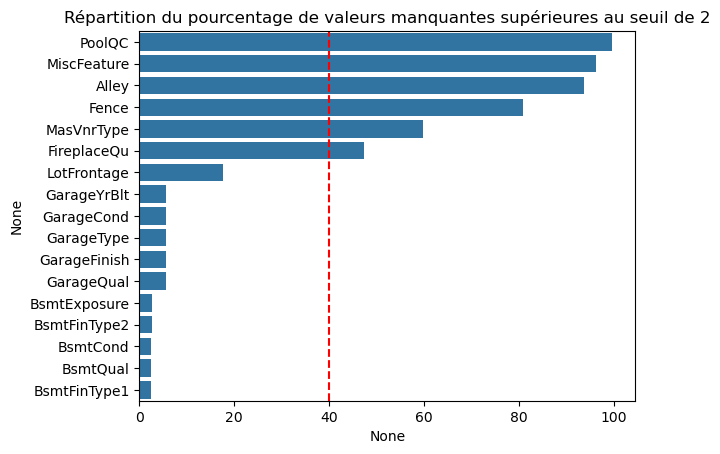

In [ ]:
threshold_view = 2

filtered = percent_missing[percent_missing.values > threshold_view]
ax = sns.barplot(x = filtered, y = filtered.index, orient='h');
ax.set_title(f"Répartition du pourcentage de valeurs manquantes supérieures au seuil de {threshold_view}");

threshold = 40

ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")

Par exemple, ici je choisi de supprimer les colonnes ayant plus de 70% de valeurs manquantes :

In [ ]:
columns_to_drop = percent_missing[
    percent_missing.values > threshold].index

In [ ]:
columns_to_drop

Index(['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu'], dtype='object')

In [ ]:
df.drop(columns_to_drop, axis='columns', inplace=True)

In [ ]:
df.shape

(1460, 74)


# Supprimer des observations:


Si la variable qui contient des données manquantes est cruciale dans l'analyse, alors mieux vaut créer un sous-échantillon et y supprimer les observations pour lesquels cette variable est manquante.

Par exemple, je peux supprimer les lignes contentant toutes des valeurs manquantes:


In [ ]:
df.dropna(how='all',inplace=False).head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [ ]:
df.shape

(1460, 74)

# Imputer les valeurs manquantes (à utiliser avec précaution !) :

Une stratégie un peu plus audacieuse (mais qui peut se réveler payante si vous souhaitez conservez plus de données) consiste à remplacer les valeurs manquantes par une valeur estimée. Il existe différentes méthodes d'imputation, variant par la méthode estimation des valeurs manquante à remplacer:

Pour des variables numériques :

## Imputation univariée

   ### l'imputation par la moyenne (ou la médiane):

On remplace chaque valeur manquante d'une variable par la moyenne (ou la mediane) des valeurs de cette variable. Pour des variables discrètes, on pourra utiliser la valeur la plus fréquente (le mode) comme estimateur des données à remplacer. Cette méthode d'imputation est implémentée dans scikit-learn par SimpleImputer

On remplace chaque valeur manquante yi par son estimation ^yi

calculé en faisant une régression à partir d'autres variables disponibles (ne contenant pas ou peu de données manquantes). Cette méthode d'imputation est implémentée dans scikit-learn par IterativeImputer





## Imputation multivariée

   ### l'imputation par la régression:

On remplace chaque valeur manquante yi
par son estimation ^yi

calculé en faisant une régression à partir d'autres variables disponibles (ne contenant pas ou peu de données manquantes). Cette méthode d'imputation est implémentée dans scikit-learn par IterativeImputer

   ### l'imputation par la méthode hot-deck aléatoire:

On remplace une valeur manquante yi par une observation sélectionnée au hasard avec remise (parmi les observations non manquantes)

   ### l'imputation par la méthode des plus proches voisin:

On remplace une valeur manquante yi
par l'observation correspondant au plus proche voisin parmi les observations non manquantes. Cette méthode d'imputation est aussi implémentée dans scikit-learn par KNNImputer


   




## Imputation univariée des variables catégorielles :

On ne peut plus utiliser les méthodes citées plus haut car elle ne sont calculables que sur des variables numériques, il faudra utiliser des méthodes d'imputation spécifiques:

   ### l'imputation par le mode:

On remplace chaque valeur manquante d'une variable par la valeur la plus fréquente (le mode) comme estimateur des données à remplacer. Cette méthode d'imputation est encore implémentée dans SimpleImputer en utilisant le kwarg strategy = most_frequent

Exemple : Imputation de la variable Electrical par la valeur la plus frequente


In [ ]:
df.loc[:,"Electrical"].isnull().sum()


1

In [ ]:
from sklearn.impute import SimpleImputer

imputation = SimpleImputer(missing_values = np.nan, 
                           strategy = 'most_frequent')
imputation.fit(df["Electrical"].values.reshape(-1,1))

SimpleImputer(strategy='most_frequent')

In [ ]:
imputation.transform(df["Electrical"].\
                     values.reshape(-1,1))

array([['SBrkr'],
       ['SBrkr'],
       ['SBrkr'],
       ...,
       ['SBrkr'],
       ['FuseA'],
       ['SBrkr']], dtype=object)

In [ ]:
df.loc[:,"Electrical"] = imputation.transform(df["Electrical"].values.reshape(-1,1))

In [ ]:
# check that there is no more missing value
df.loc[:,"Electrical"].isnull().sum()

0

### Imputation des variables numériques restantes

Dans cet exemple on va faire une imputation multivariée (en sélectionnant uniquement les variables numériques) 

In [ ]:
numeric_features = df.select_dtypes(include=['float','int'])
numeric_features.shape

(1460, 37)

In [ ]:
from sklearn.impute import KNNImputer
imputation = KNNImputer(missing_values=np.nan)
imputed = imputation.fit_transform(numeric_features)
imputed.shape

(1460, 37)

In [ ]:
df.loc[:,numeric_features.columns] = imputed
numeric_features.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath',
       'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
       'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrSold', 'SalePrice'],
      dtype='object')

### Effet de l'imputation


In [ ]:
def compare_dist(feature):
    fig, axes = plt.subplots(1,2,figsize=(12,3))
    ax=axes[0]
    sns.histplot(raw_df.loc[:,feature],kde=True, ax=ax)
    ax.set_title(f"Raw {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    ax=axes[1]
    sns.histplot(df.loc[:,feature],kde=True, ax=ax)
    ax.set_title(f"Imputed {feature}")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

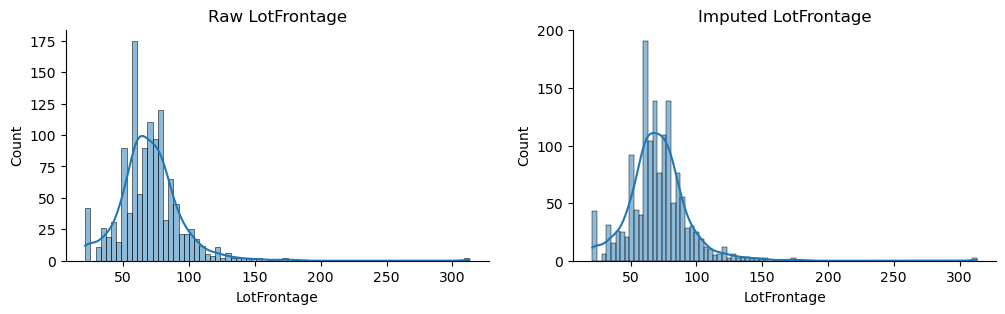

In [ ]:
compare_dist("LotFrontage")

### Danger de l'imputation 

L'imputation doit être utilisé avec précaution car elle introduit à la place des observations manquantes, des données estimées. En conséquence, en fonction de la pertinence et de la justesse de ces estimations, vous risquez d'affecter négativement les performances de votre algorithme de manchine learning.

En particulier, il vous faudra prendre des précautions et vérifier en explorant les données que votre imputation:
   * ne modifie pas de manière drastique les relations entre les variables
   * ne modifie pas de manière drastique la variance de l'estimation de votre variable d'intérêt (dans le cas de l'apprentissage supervisé, il s'agira de votre estimation des labels y ou de la variable à optimiser dans le cas du clustering (par exemple l'inertie dans le cas de K-means))

## Les Outliers

Un outlier peut désigner une valeur aberrante (une valeur probablement erronnée) ou une valeur atypique (qui est inhabituelle mais pas forcément fausse).

En général, il est assez souvent difficile de distinguer ces deux cas de figure pour un outlier, la meilleure solution à votre portée reste d'explorer vos données en calculant des indicateurs statistiques (mediane, ecart-type, corrélations, ...) et en utilisant des visualisations de données

### Les outliers  / Identification et traitement des outliers

Les identifier supprimer manuellement (par exploration des données)
   
   #### Avec le critère de Tukey

Une convention consiste à utiliser le critère de **Tukey** pour représenter les outliers comme des points se situant en dehors des moustaches d'un diagramme à moustache, ou boxplot



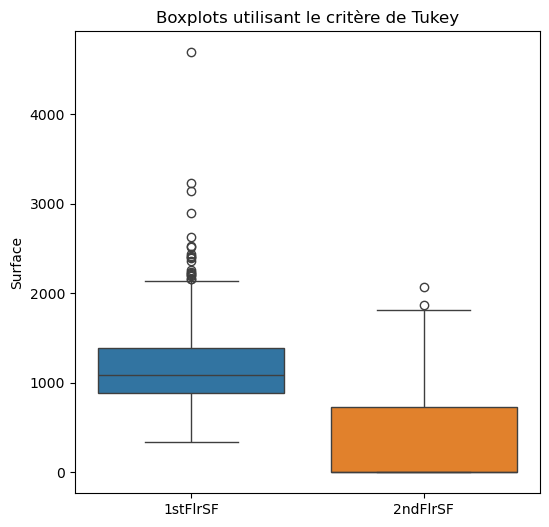

In [ ]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6,6))
sns.boxplot(data=df.loc[:,["1stFlrSF","2ndFlrSF"]]);
ax.set_ylabel("Surface");
ax.set_title("Boxplots utilisant le critère de Tukey");



Attention, ce critère n'est qu'indicatif, il convient de continuer à explorer les données suspectées, par exemple avec un scatter plot :


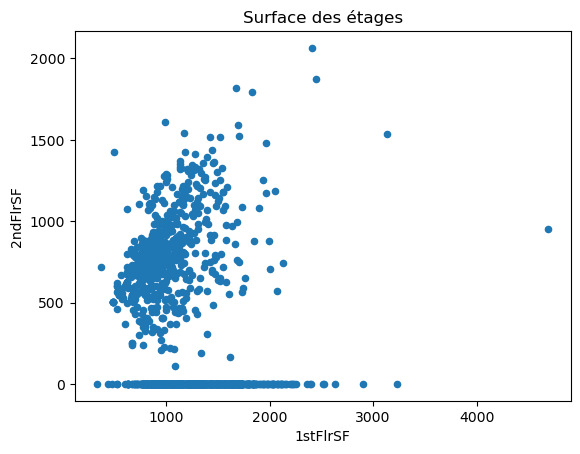

In [ ]:
ax = df.plot(kind='scatter', 
             x="1stFlrSF", 
             y= "2ndFlrSF")
ax.set_title("Surface des étages");


Avec des méthodes automatiques


Il est possible d'utiliser des modèles de machine learning spécifiquement entraînés pour détecter des identifier la frontière séparant les inliers des données outliers

Conserver ces valeurs ?




Par exemple, scikit-learn propose plusieurs méthodes décrites dans cette page dédiée

https://scikit-learn.org/stable/modules/outlier_detection.html#novelty-and-outlier-detection


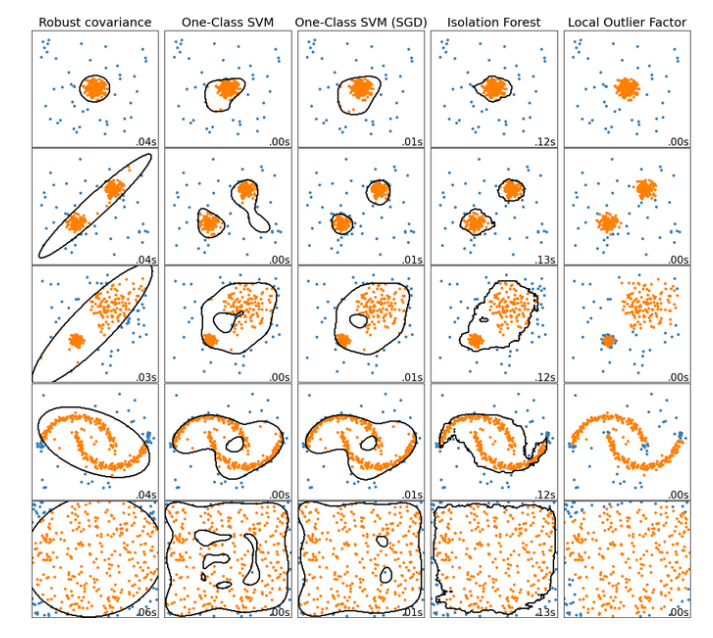


Conserver ces valeurs ?

Si vous avez des doutes, conservez les outliers qui pourraient être des valeurs atypiques. Dans ce cas, vous avez plutôt intérêt dans ce cas à utiliser des méthodes d'analyse robustes aux outliers, comme par exemple les modèles qui utilisent des méthodes de régularisation (c'est le cas par exemple des regression ridge et lasso)

Dans tous les cas, je vous conseille d'avoir une démarche itérative et de mesurer à quel point vos traitements affectent la performance générale de vos analyses !




# Etapes de traitements supplémentaires

Nous allons voir maintenant d'autres étapes, non indispensables, mais souvent nécessaires dans certaines tâches de data science, en particulier pour le machine learning 

## Encodage des variables catégorielles

Cette étape de traitement consiste à encoder les variables catégorielles en variables numériques afin qu'elle soient utilisables par la plupart des algorithmes de traitement de données. Il existe différentes façons de réaliser cet encodage, par exemple :

### Encodage des labels (target)



On utilise label encoder qui recode les valeurs de la variable target en valeur numérique de 0 à nclasses−1

In [ ]:
from sklearn import preprocessing

le = preprocessing.LabelEncoder()
le.fit_transform(["paris", "paris", "tokyo", "amsterdam"])

array([1, 1, 2, 0], dtype=int64)


### Encodage des features

Pour encoder des les features catégorielles ordinales, on peut utiliser l'outil ordinal encoder qui va les transformer en série de nombre en préservant la relation d'ordre




In [ ]:
oe = preprocessing.OrdinalEncoder()
X = [['Small', 1], ['Tall', 3], ['Tall', 2]] 
oe.fit_transform(X)

array([[0., 0.],
       [1., 2.],
       [1., 1.]])

In [ ]:
oe = preprocessing.OrdinalEncoder()
X = [['Small', 20], ['Tall',333], ['Tall', 42]] 
oe.fit_transform(X)

array([[0., 0.],
       [1., 2.],
       [1., 1.]])

En revanche, pour les variables catégorielles qui sont non ordinales, afin de ne pas introduire de hiérarchie entre les catégories, on utilise généralement le one-hot-encoder

En pratique, on peut sélectionner toutes les variables catégorielles en utilisant select_dtypes :

In [ ]:
df.select_dtypes('object').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 37 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   MSZoning       1460 non-null   object
 1   Street         1460 non-null   object
 2   LotShape       1460 non-null   object
 3   LandContour    1460 non-null   object
 4   Utilities      1460 non-null   object
 5   LotConfig      1460 non-null   object
 6   LandSlope      1460 non-null   object
 7   Neighborhood   1460 non-null   object
 8   Condition1     1460 non-null   object
 9   Condition2     1460 non-null   object
 10  BldgType       1460 non-null   object
 11  HouseStyle     1460 non-null   object
 12  RoofStyle      1460 non-null   object
 13  RoofMatl       1460 non-null   object
 14  Exterior1st    1460 non-null   object
 15  Exterior2nd    1460 non-null   object
 16  ExterQual      1460 non-null   object
 17  ExterCond      1460 non-null   object
 18  Foundation     1460 non-null



Pour l'exemple, encodons les variable LotShape and HouseStyle:


In [ ]:
df.loc[:,['LotShape','HouseStyle']].head()

,LotShape,HouseStyle
0,Reg,2Story
1,Reg,1Story
2,IR1,2Story
3,IR1,2Story
4,IR1,2Story




On définit et entraine un OneHotEncoder :


In [ ]:
from sklearn.preprocessing import OneHotEncoder
enc = OneHotEncoder()
enc.fit(df.loc[:,['LotShape','HouseStyle']])

OneHotEncoder()



On peut regarder les catégories unique qui vont être encodées :


In [ ]:
enc.categories_

[array(['IR1', 'IR2', 'IR3', 'Reg'], dtype=object),
 array(['1.5Fin', '1.5Unf', '1Story', '2.5Fin', '2.5Unf', '2Story',
        'SFoyer', 'SLvl'], dtype=object)]



On applique ensuite la transformation :


In [ ]:
encoded_features = enc.transform(df.loc[:,['LotShape','HouseStyle']]).toarray()
encoded_features

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])



Scikit-learn permet aussi récupérer le nom des features encodées :


In [ ]:
encoded_features_names = enc.get_feature_names_out()
encoded_features_names

array(['LotShape_IR1', 'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg',
       'HouseStyle_1.5Fin', 'HouseStyle_1.5Unf', 'HouseStyle_1Story',
       'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_2Story',
       'HouseStyle_SFoyer', 'HouseStyle_SLvl'], dtype=object)



ou l'afficher dans un data frame :


In [ ]:
pd.DataFrame(encoded_features,
            columns = encoded_features_names)

,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1456,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1457,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1458,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


# Scaling des données numériques

Cette étape de traitement consiste à transformer les variables continues ayant des ordres de grandeur différents en des variables ayant des ordres de grandeur comparables. Bien que généralement non indispensable au fonctionnement direct de votre chaîne de traitement, il est souhaitable de l'utiliser pour:

   * Empecher les variables avec des variations de grande amplitude de prendre artificiellement plus d'importance dans votre modèle que celle ayant des variations de faible amplitude (par une mesure de temperatures en °C par rapport a une mesure de tailles de personnes en m)
   *  Le scaling permet d'interpréter plus facilement l'importance relative des variables pour votre modèle
   * Le scaling permet de diminuer les temps de calcul puisqu'il diminue l'ordre de grandeur des variables


## La standardisation

Elle consiste à simplement changer l'ordre de grandeur de vos variable, sans changer leur distribution. On transforme la variable initiale X
en X′

suivant:
X′= X−Xmin / Xmax−Xmin



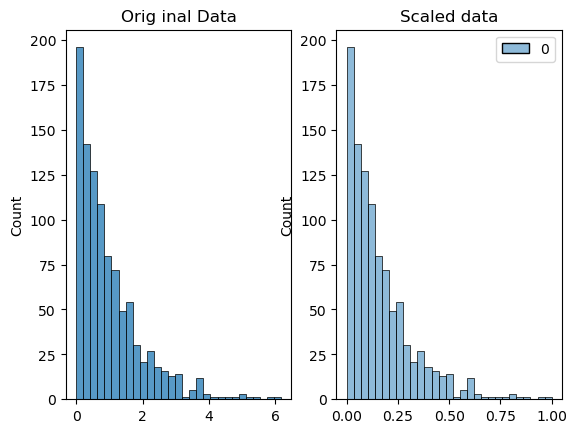

In [ ]:
import numpy as np
import seaborn as sns
from mlxtend.preprocessing import minmax_scaling
import matplotlib.pyplot as plt

# generate 1000 data points randomly drawn from an exponential distribution
original_data = np.random.exponential(size=1000)

# mix-max scale the data between 0 and 1
scaled_data = minmax_scaling(original_data, columns=[0])

# plot both together to compare
fig, ax = plt.subplots(1,2);
sns.histplot(original_data, ax=ax[0]);
ax[0].set_title("Orig inal Data");
sns.histplot(scaled_data, ax=ax[1]);
ax[1].set_title("Scaled data");


## La normalisation

Elle consiste à modifier la distribution de votre variable d'intérêt pour qu'elle suive une distribution normale. Cette transformation est parfois un prérequis statistique pour certains modèle (comme le Naive Bayes ou généralement les modèles impliquant une gaussienne), dans ce cas il est impératif de l'appliquer. On transforme la variable initiale X
en X′

qui va varier entre 0 et 1:
X′=X−mean(X)/std(X)





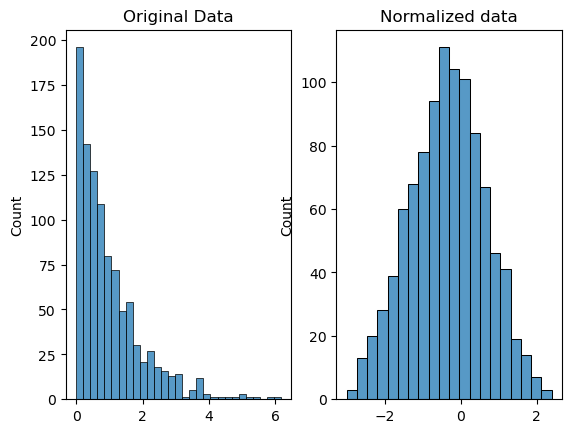

In [ ]:

from scipy import stats

# normalize the exponential data with boxcox
normalized_data = stats.boxcox(original_data)

# plot both together to compare
fig, ax=plt.subplots(1,2);
sns.histplot(original_data, ax=ax[0]);
ax[0].set_title("Original Data")
sns.histplot(normalized_data[0], ax=ax[1]);
ax[1].set_title("Normalized data");


## Le scaling robuste aux outliers


Un des problème potentiel avec la standardisation et normalisation est qu'elle est sont sensibles aux outliers (dans leur formule on va utiliser les valeurs extrêmes contenues dans les données ou la variance qui sont sensible aux outliers).

Dans le cas où vos données contiennent encore des outliers, vous pouvez utiliser une méthode de scaling robuste aux outliers (dont le calcul n'est pas trop affecté par leur présence). Par exemple, en utilisant la formule:
X′= X−median(X) / IQR(X)

où IQR(X) désigne l'Inter Quartile Range (l'écart inter quartile).
Cette méthode est implémentée dans scikit-learn avec la classe RobustScaler




## Autres méthodes de scaling

Il existe d'autres méthodes de scaling, vous pouvez consultez ce notebook pour visualiser leur effet sur les données


## Equilibrage des données (balancing)

Cet traitement s'avère nécessaire lorsque le nombre d'observation par classe est fortement déséquilibré: certaines classes peuvent être sous repésentées ou sur représentées, par rapport aux autres classes (par exemple 30% vs 70%)

En apprentissage supervisé, ce problème impacte souvent fortement les performances des algorithmes utilisés: leurs perfomances sera souvent particulièrement mauvaise pour les classes sous représentées (l'algorithme aura plus de mal à généraliser)


### Méthodes de ré-échantillonnage aléatoire



Pour pallier à ce problèmes on peut utiliser différentes stratégies, les plus simples étant:

    le sous echantillonnage au hasard de la classe majoritaire (random under sampling majority)
    le sur enchantillonnage par duplication, au hasard, de la classe minoritaire (random over sampling minority)

⚠ Attention, les méthodes de sur echantillonnage peuvent causer du data leakage (de l'information provenant d'autre part que le data set d'entrainement est utilisée pour entrainer le modèle) ! 



### Méthodes de ré-échantillonnage avancées



Il existe des méthodes de sous échantillonage plus avancées, SMOTE et sa variation, ADASYN opèrent en fabriquant de nouvelles observations de la classe minoritaire en combinant linéairement les observations provenant de la classe sous représentée

SMOTE et ASASYN sont des méthodes de sur échantillonnage, qui génèrent de nouvelles observations à partir d'observations de la classe minoritaire, en se basant sur des combinaisons linéaires du vecteur constitué à partir de chacune de ces observations avec ses k plus proches voisins


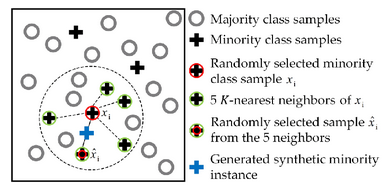


#### Illustration de l'application de ces méthodes de ré-échantillonnage

https://imbalanced-learn.org/stable/over_sampling.html#from-random-over-sampling-to-smote-and-adasyn


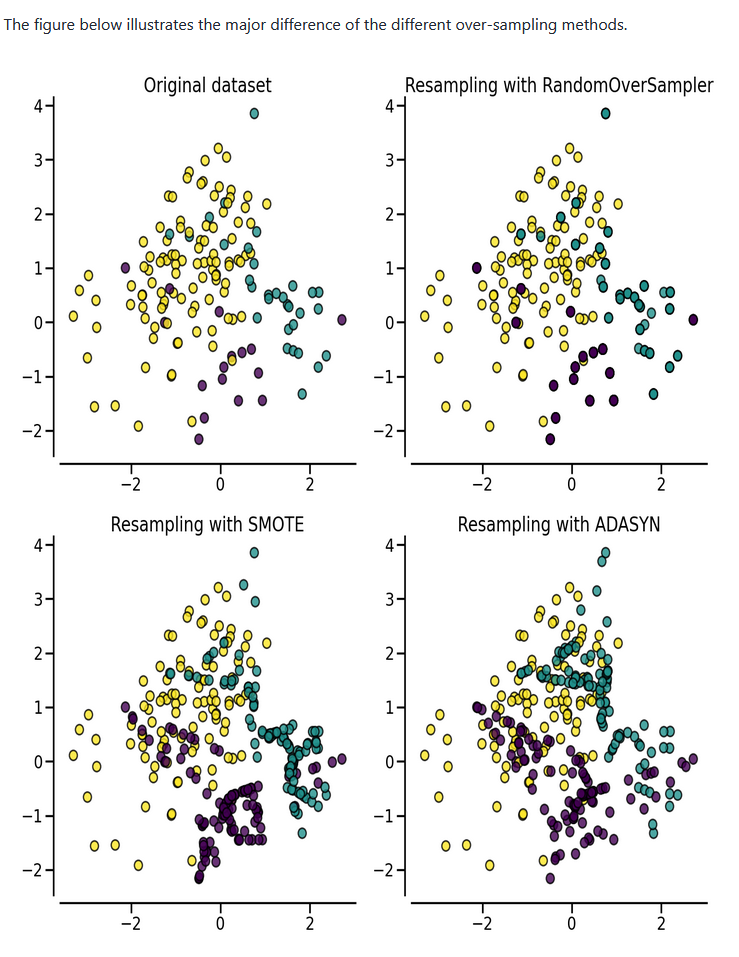


Apart from the random sampling with replacement, there are two popular methods to over-sample minority classes: (i) the Synthetic Minority Oversampling Technique (SMOTE) [CBHK02] and (ii) the Adaptive Synthetic (ADASYN) [HBGL08] sampling method. These algorithms can be used in the same manner:


⚠ Attention, on n'utilise les méthodes de ré-échantilonnage que sur le data set d'entrainement, uniquement pour l'apprentissage du modèle. On souhaite garder le data set de test aussi représentatif possible de la réalité !




# Discretisation des données

On applique ce traitement lorsque l'on souhaite transformer une variable continue en faisant des paquets (bins) pour la rendre discrete. Cela peut servir, par exemple:

    à transformer une tâche de regression en tâche de classification
    faire du feature engineering pour donner plus d'efficacité au modèle



In [ ]:
import pandas as pd
import numpy as np
pd.cut(np.array([1, 7, 5, 4, 6, 3]),3, labels=["bad", "medium", "good"])

['bad', 'good', 'medium', 'medium', 'good', 'bad']
Categories (3, object): ['bad' < 'medium' < 'good']

In [ ]:
df['SalePriceBinary'] = pd.cut(x = df['SalePrice'],
                       bins=[df['SalePrice'].min()-1,
                             df['SalePrice'].mean(),
                             df['SalePrice'].max()+1], 
                       labels=['cheap', 'expensive'])

In [130]:
pd.cut(np.array([1, 7, 5, 4, 6, 3]), 2)

[(0.994, 4.0], (4.0, 7.0], (4.0, 7.0], (0.994, 4.0], (4.0, 7.0], (0.994, 4.0]]
Categories (2, interval[float64, right]): [(0.994, 4.0] < (4.0, 7.0]]

In [ ]:
df.loc[0:3,['SalePrice','SalePriceBinary']]

,SalePrice,SalePriceBinary
0,208500,expensive
1,181500,expensive
2,223500,expensive
3,140000,cheap


# Améliorer l'information contenue dans le data set








# Création de features

Cet traitement n'est pas indispensable mais consiste à ajouter de l'information en fabriquant de nouvelles features, pour tenter d'améliorer les performances du modèle

   * On peut créer des features par différentes méthodes:
   

   * Sur la base d'intutition mathématiques, par exemple en introduisant des features polynomiales:
   Exemple : transformer un set de feature (X1,X2) en (X1,X2,X21,X1X2,X22)
   

   * On peut les créer en utilisant des connaissances du domaine, par exemple:
   en calculant le BodyMassIndex: heightmass2


   * Ou en tentant d'ajouter des informations supplémentaires provenant d'autres sources, comme: ajouter une variable concernant la présence d'un starbuck près d'une gare dans un problème visant à prédire la fréquentation

# Sélection de features

Ce traitement consiste à éliminer les features les moins informatives de votre data set afin d'obtenir le modèle le plus parcimonieux, c.a.d celui qui le modèle le plus performant avec le moins de features possibles.

### Avantages



* Réduit le bruit dans les données dues au features peu ou pas informatives

* Réduit la complexité du modèle

*  Evite le problème du fléau de la dimension

*  Favorise l'interprétabilité du modèle

* Réduit le cout computationnel



# Fléau de la dimension



La performance décroit lorsque on dépasse un nombre critique de features


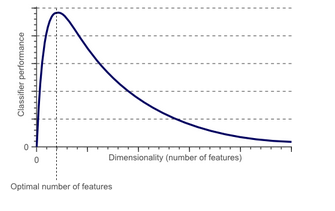



Le nombre de données nécessaires augmente exponentiellement avec le nombre de features (dimensions).

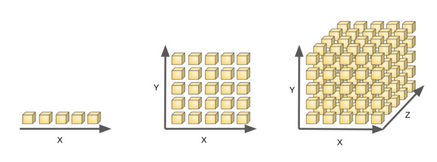

Une règle du pouce !!

Attention au one-hot-encoder !!!


# Sélection de features univariées


## Corrélation de Pearson

Une des plus simple méthode de sélection consiste à éliminer les features les plus corrélées entre elles, puisqu'elles sont fortement dépendantes et apportent une information redondante

## Par seuil: suppression des features moins bien classés


Dans cette famille de méthodes on classe les features en calculant un score, puis on supprime les features les moins bien classées

Dans scikit-learn, SelectKbest SelectPercentile, ... sélectionnent les features qui obtiennent les meilleurs scores suivant un critère statistique donné, comme par exemple un test statistique d'indépendance (χ2)

Example avec le dataset Iris qui contient 4 features:

Sélection de features multi-variées





In [ ]:
from sklearn.datasets import load_iris
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
X, y = load_iris(return_X_y=True)
X.shape

(150, 4)

In [ ]:
X_new = SelectKBest(chi2, k=2).fit_transform(X, y)
X_new.shape

(150, 2)



On a sélectionné deux features parmi les 4.

Voir en détail l'effet d'une méthode sélection de feature univariée dans cet exemple
Sélection de features multi-variées




# Sélection de features multi-variées

## Méthodes intrinsèques

Il s'agit de méthodes spécifiques à une classe de modèles comme:

la pénalisation des coefficients de modèles de régression ou classification des méthodes spécifiques aux arbres de décision

    

## Les méthodes de type wrapper


Le principe de ces méthodes consiste à combiner différentes combinaisons de "paquets" de features simultanément (et prenant en compter leur interactions) et garder celles qui favorisent un score élevé du modèle

Par exemple l'elimination récurive de feature procède suivant ces étapes:

à partir de l'ensemble des features de départ, on calcule leur importance on supprime les features les moins importantes. La procédure est répéte jusqu'a obtenir un nombre désiré de feature
    
## Méthodes Séquentielles

Le principe de ces méthodes consiste à ajouter ou supprimer séquentiellement des features jusqu'a atteindre un seuil défini par un critère quantifiant la qualité du modèmle testé, comme l'AIC ou le BIC

   * dans les méthodes ascendantes on part de zero feature, puis on rajoute séquentiellement des features
   * dans les méthodes descendantes, on part du set initial de feature, puis on supprime séquentiellement des variables

## La réduction de dimensionalité

Certaines méthodes de décomposition de matrice comme l'Analyse en Composante Principale ou la Décomposition en Valeur Singulière permettent de trouver une nouvel espace vectoriel pour représenter les variables de votre dataset (plongement), qui exploite mieux certaines propriétés statistiques des données.

Dans ce nouvel, espace, les variables sont exprimées à partir de vecteurs propres, on peut supprimer certaines variables ayant des valeurs propres peu éléves, sans perdre trop d'information.
Par exemple, on peut ranger les composantes ainsi calculées par pourcentage de variance expliquée :

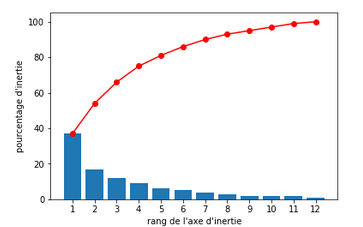


On peut ensuite faire le plongement inverse pour exprimer les variables à partir de l'espace vectoriel de départ, et on obtient alors un data set reconstruit avec moins de variables
Attention au data leakage !






## Attention au data leakage !


Le **data leakage** (fuite de données) est un phénomène qui survient lorsque l'on utilise, au moment de l'apprentissage de l'information qui ne devrait pas être accessible au modèle.

!!! C'est un phénomène a éviter absolument car il risque de compromettre la capacité de votre modèle à généraliser !!!

Par exemple, si vous faites un scaling de variable en utilisant la totalité du data set, lorsque vous allez faire une validation croisée, vous utiliserez dans les folds pour la validation, des variables ayant été scalées à partir de tout le data set


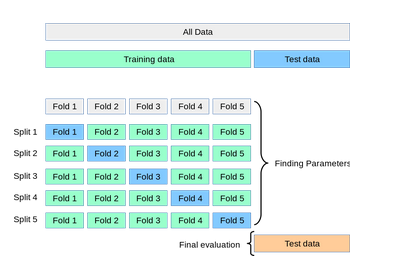




Solution : Utiliser l'objet pipeline de sckit-learn pour exécuter le scaling pendant la cross validation

Voir cet article pour apprendre en détail les différents cas de data leakage


# train_test_split


